## Cell 1 — Install & Import

In [1]:
import subprocess, sys
for pkg in ['pandas','numpy','scikit-learn','xgboost','shap','matplotlib','seaborn','joblib','tqdm']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay)
import xgboost as xgb
import shap
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
print(' Imports complete')

 Imports complete


## Cell 2 — Feature Engineering (Same as Notebook 2)

In [2]:
RISKY_TLDS = {'xyz','tk','ml','gq','cf','pw','cc','info','win',
              'top','click','ru','biz','online','site'}

def engineer_features(df):
    feat = pd.DataFrame()
    spf_map  = {'pass':4,'neutral':3,'softfail':2,'none':1,'fail':0,
                'permerror':0,'present_unverified':2,'present_unsigned':2}
    dkim_map = {'pass':3,'none':1,'fail':0,'temperror':0,
                'present_unverified':2,'present_unsigned':2}
    dmarc_map= {'pass':3,'none':2,'quarantine':1,'fail':0,'reject':0}
    pol_map  = {'reject':3,'quarantine':2,'none':1}

    feat['spf_score']      = df['spf_result'].map(spf_map).fillna(0)
    feat['spf_pass']       = (df['spf_result']=='pass').astype(int)
    feat['spf_fail']       = df['spf_result'].isin(['fail','permerror']).astype(int)
    feat['spf_softfail']   = (df['spf_result']=='softfail').astype(int)
    feat['spf_none']       = (df['spf_result']=='none').astype(int)

    feat['dkim_score']     = df['dkim_result'].map(dkim_map).fillna(0)
    feat['dkim_pass']      = (df['dkim_result']=='pass').astype(int)
    feat['dkim_fail']      = df['dkim_result'].isin(['fail','temperror']).astype(int)
    feat['dkim_none']      = (df['dkim_result']=='none').astype(int)

    feat['dmarc_result_score'] = df['dmarc_result'].map(dmarc_map).fillna(0)
    feat['dmarc_policy_score'] = df['dmarc_policy'].map(pol_map).fillna(0)
    feat['dmarc_pass']         = (df['dmarc_result']=='pass').astype(int)
    feat['dmarc_fail']         = df['dmarc_result'].isin(['fail','reject']).astype(int)
    feat['dmarc_align_spf']    = (df['dmarc_alignment_spf']=='pass').astype(int)
    feat['dmarc_align_dkim']   = (df['dmarc_alignment_dkim']=='pass').astype(int)
    feat['dmarc_both_aligned'] = (feat['dmarc_align_spf'] & feat['dmarc_align_dkim']).astype(int)
    feat['dmarc_none_align']   = (~feat['dmarc_align_spf'].astype(bool) &
                                   ~feat['dmarc_align_dkim'].astype(bool)).astype(int)

    feat['all_auth_pass']    = (feat['spf_pass'] & feat['dkim_pass'] & feat['dmarc_pass']).astype(int)
    feat['auth_failures']    = feat['spf_fail'] + feat['dkim_fail'] + feat['dmarc_fail']
    feat['auth_total_score'] = feat['spf_score'] + feat['dkim_score'] + feat['dmarc_result_score']

    feat['domain_aligned']      = df['domain_alignment_match'].astype(int)
    feat['is_spoofed']          = df['is_spoofed'].astype(int)
    feat['header_domain_len']   = df['header_from_domain'].str.len().fillna(0)
    feat['envelope_domain_len'] = df['envelope_from_domain'].str.len().fillna(0)
    feat['domain_len_diff']     = abs(feat['header_domain_len']-feat['envelope_domain_len'])

    def tld_risk(d):
        if pd.isna(d): return 0
        return 1 if str(d).split('.')[-1].lower() in RISKY_TLDS else 0
    def has_digit(d):
        if pd.isna(d): return 0
        return 1 if any(c.isdigit() for c in str(d).split('.')[0]) else 0

    feat['header_domain_risky_tld']   = df['header_from_domain'].apply(tld_risk)
    feat['envelope_domain_risky_tld'] = df['envelope_from_domain'].apply(tld_risk)
    feat['digit_in_header_domain']    = df['header_from_domain'].apply(has_digit)
    feat['digit_in_envelope_domain']  = df['envelope_from_domain'].apply(has_digit)
    feat['hyphen_in_domain']          = df['header_from_domain'].str.contains('-',na=False).astype(int)

    feat['hop_count']        = pd.to_numeric(df['hop_count'],errors='coerce').fillna(1)
    feat['high_hop_count']   = (feat['hop_count']>=5).astype(int)

    import re
    def reply_mismatch(row):
        try:
            rt = re.sub(r'[<>]','',str(row.get('reply_to',''))).split('@')[-1].strip()
            hd = str(row.get('header_from_domain','')).strip()
            return 0 if rt==hd else 1
        except: return 0
    feat['reply_to_mismatch'] = df.apply(reply_mismatch, axis=1)

    feat['spam_score']           = pd.to_numeric(df['x_spam_score'],errors='coerce').fillna(0)
    feat['spam_score_high']      = (feat['spam_score']>=5.0).astype(int)
    feat['spam_score_very_high'] = (feat['spam_score']>=8.0).astype(int)

    feat['arc_fail'] = df['arc_seal'].str.contains('cv=fail',na=False).astype(int)
    feat['arc_pass'] = df['arc_seal'].str.contains('cv=pass',na=False).astype(int)

    feat['spf_dkim_both_fail']  = (feat['spf_fail'] & feat['dkim_fail']).astype(int)
    feat['spoofed_and_spammy']  = (feat['is_spoofed'] & feat['spam_score_high']).astype(int)
    feat['misalign_dmarc_fail'] = (~feat['domain_aligned'].astype(bool) &
                                    feat['dmarc_fail'].astype(bool)).astype(int)
    feat['risky_tld_auth_fail'] = (feat['header_domain_risky_tld'] &
                                   (feat['auth_failures']>0)).astype(int)
    return feat

print(' Feature engineering ready')

 Feature engineering ready


## Cell 3 — Load & Combine Datasets

In [13]:
print(' Loading datasets...')

# Load synthetic
if not os.path.exists('email_security_dataset.csv'):
    raise FileNotFoundError('email_security_dataset.csv not found. Run Notebook 1 first.')
df_synth = pd.read_csv('email_security_dataset.csv')
print(f' Synthetic: {len(df_synth):,} records')

# Load real
df_real = None
if os.path.exists('real_emails_combined.csv'):
    df_real = pd.read_csv('real_emails_combined.csv')
    print(f' Real data: {len(df_real):,} records')
    print(f'   Labels: {df_real["label"].value_counts().to_dict()}')
else:
    print('  real_emails_combined.csv not found')
    print('   Running on synthetic data only')
    print('   Run phishing_pot_parser.ipynb first for real data')

# Fill missing values in real data
def fill_defaults(df):
    defaults = {
        'spf_result':'none','dkim_result':'none','dmarc_result':'none',
        'dmarc_policy':'none','dmarc_alignment_spf':'fail',
        'dmarc_alignment_dkim':'fail','domain_alignment_match':False,
        'is_spoofed':True,'x_spam_score':0,'hop_count':1,
        'header_from_domain':'unknown','envelope_from_domain':'unknown',
        'arc_seal':'none','reply_to':'','attack_pattern':'unknown'
    }
    for col, val in defaults.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

df_synth = fill_defaults(df_synth)
if df_real is not None:
    df_real = fill_defaults(df_real)

print(f'\n Data loaded and cleaned')

 Loading datasets...
 Synthetic: 100,000 records
 Real data: 7,076 records
   Labels: {'phishing': 7076}

 Data loaded and cleaned


## Cell 4 — Split Real Data (80% Train / 20% Test)

In [14]:
from sklearn.model_selection import train_test_split

if df_real is not None and len(df_real) > 10:
    # Split real data: 80% train, 20% honest test
    df_real_train, df_real_test = train_test_split(
        df_real, test_size=0.20, random_state=42,
        stratify=df_real['label'] if df_real['label'].nunique() > 1 else None
    )
    print(f' Real data split:')
    print(f'   Train (80%): {len(df_real_train):,} records')
    print(f'   Test  (20%): {len(df_real_test):,} records (HELD OUT for honest evaluation)')

    # Combine synthetic + real train
    df_combined_train = pd.concat([df_synth, df_real_train], ignore_index=True)
    df_combined_train = df_combined_train.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f'\n Combined training set:')
    print(f'   Total: {len(df_combined_train):,} records')
    print(f'   {df_combined_train["label"].value_counts().to_dict()}')

    USE_COMBINED = True
else:
    # Synthetic only
    df_combined_train = df_synth
    df_real_test = None
    print('  Using synthetic data only for training')
    USE_COMBINED = False

# Synthetic test set (20% of synthetic)
df_synth_train, df_synth_test = train_test_split(
    df_synth, test_size=0.20, random_state=42,
    stratify=df_synth['label']
)
print(f'\n Synthetic test set: {len(df_synth_test):,} records (for comparison)')

 Real data split:
   Train (80%): 5,660 records
   Test  (20%): 1,416 records (HELD OUT for honest evaluation)

 Combined training set:
   Total: 105,660 records
   {'legitimate': 60000, 'spam': 25000, 'phishing': 20660}

 Synthetic test set: 20,000 records (for comparison)


## Cell 5 — Prepare Features & Labels

In [15]:
le = LabelEncoder()

# Training features
print('⚙️  Engineering features...')
X_train = engineer_features(df_combined_train)
y_train = le.fit_transform(df_combined_train['label'])

feature_cols = list(X_train.columns)

# Synthetic test features
X_synth_test = engineer_features(df_synth_test)
X_synth_test = X_synth_test.reindex(columns=feature_cols, fill_value=0)
y_synth_test = le.transform(df_synth_test['label'])

# Real test features
if df_real_test is not None:
    X_real_test = engineer_features(df_real_test)
    X_real_test = X_real_test.reindex(columns=feature_cols, fill_value=0)
    # Map real labels to known classes
    known_labels = set(le.classes_)
    df_real_test_filtered = df_real_test[
        df_real_test['label'].isin(known_labels)
    ].reset_index(drop=True)
    X_real_test = engineer_features(df_real_test_filtered)
    X_real_test = X_real_test.reindex(columns=feature_cols, fill_value=0)
    y_real_test = le.transform(df_real_test_filtered['label'])
    print(f' Real test filtered: {len(df_real_test_filtered):,} records')

print(f' Features ready')
print(f'   Training : {X_train.shape}')
print(f'   Features : {len(feature_cols)}')
print(f'   Classes  : {list(le.classes_)}')

⚙️  Engineering features...
 Real test filtered: 1,416 records
 Features ready
   Training : (105660, 42)
   Features : 42
   Classes  : ['legitimate', 'phishing', 'spam']


## Cell 6 — Train Random Forest on Combined Data

In [16]:
print(' Training Random Forest on combined dataset...')
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt',
    class_weight='balanced', n_jobs=-1,
    random_state=42, oob_score=True
)
rf_model.fit(X_train, y_train)
elapsed = time.time() - t0

# Evaluate on synthetic test
y_pred_synth = rf_model.predict(X_synth_test)
rf_synth_f1  = f1_score(y_synth_test, y_pred_synth, average='weighted')

print(f' Random Forest trained in {elapsed:.1f}s')
print(f'   OOB Score          : {rf_model.oob_score_:.4f}')
print(f'   Synthetic Test F1  : {rf_synth_f1:.4f}')

if df_real_test is not None:
    y_pred_real = rf_model.predict(X_real_test)
    rf_real_f1  = f1_score(y_real_test, y_pred_real, average='weighted', zero_division=0)
    print(f'   Real Test F1       : {rf_real_f1:.4f}  ← honest score')

joblib.dump(rf_model, 'models/random_forest_combined.pkl')
print(' Saved: models/random_forest_combined.pkl')

 Training Random Forest on combined dataset...
 Random Forest trained in 9.4s
   OOB Score          : 0.9984
   Synthetic Test F1  : 0.9991
   Real Test F1       : 0.9996  ← honest score
 Saved: models/random_forest_combined.pkl


## Cell 7 — Train XGBoost on Combined Data

In [17]:
from collections import Counter

print(' Training XGBoost on combined dataset...')
t0 = time.time()

counts = Counter(y_train)
total  = len(y_train)
weights = {c: total/(len(counts)*n) for c,n in counts.items()}
sample_weights = np.array([weights[y] for y in y_train])

xgb_model = xgb.XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    min_child_weight=3, gamma=0.1,
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
elapsed = time.time() - t0

y_pred_synth_xgb = xgb_model.predict(X_synth_test)
xgb_synth_f1 = f1_score(y_synth_test, y_pred_synth_xgb, average='weighted')

print(f' XGBoost trained in {elapsed:.1f}s')
print(f'   Synthetic Test F1  : {xgb_synth_f1:.4f}')

if df_real_test is not None:
    y_pred_real_xgb = xgb_model.predict(X_real_test)
    xgb_real_f1 = f1_score(y_real_test, y_pred_real_xgb, average='weighted', zero_division=0)
    print(f'   Real Test F1       : {xgb_real_f1:.4f}  ← honest score')

joblib.dump(xgb_model, 'models/xgboost_combined.pkl')
print(' Saved: models/xgboost_combined.pkl')

 Training XGBoost on combined dataset...
 XGBoost trained in 7.8s
   Synthetic Test F1  : 0.9998
   Real Test F1       : 0.9996  ← honest score
 Saved: models/xgboost_combined.pkl


## Cell 8 — Ensemble + Gap Analysis

In [18]:
RF_W, XGB_W = 0.40, 0.60

def ensemble_proba(X):
    return RF_W * rf_model.predict_proba(X) + XGB_W * xgb_model.predict_proba(X)

def ensemble_predict(X):
    return np.argmax(ensemble_proba(X), axis=1)

# Synthetic test
y_ens_synth = ensemble_predict(X_synth_test)
ens_synth_f1 = f1_score(y_synth_test, y_ens_synth, average='weighted')

print('='*60)
print('  SYNTHETIC vs REAL PERFORMANCE GAP ANALYSIS')
print('='*60)
print(f'  Training data      : {"Synthetic + Real" if USE_COMBINED else "Synthetic only"}')
print(f'  Training records   : {len(X_train):,}')
print()
print(f'  Random Forest  synthetic F1 : {rf_synth_f1:.4f}')
print(f'  XGBoost        synthetic F1 : {xgb_synth_f1:.4f}')
print(f'  Ensemble       synthetic F1 : {ens_synth_f1:.4f}')

if df_real_test is not None:
    y_ens_real = ensemble_predict(X_real_test)
    ens_real_f1 = f1_score(y_real_test, y_ens_real, average='weighted', zero_division=0)
    gap = ens_synth_f1 - ens_real_f1

    print()
    print(f'  Ensemble       real F1      : {ens_real_f1:.4f}  ← HONEST SCORE')
    print(f'  Performance gap            : {gap:.4f} ({gap*100:.1f}%)')
    print()

    if gap > 0.20:
        print('    LARGE GAP: model partially overfit to synthetic patterns')
        interp = 'large'
    elif gap > 0.10:
        print('   MODERATE GAP: some overfitting but reasonable generalization')
        interp = 'moderate'
    else:
        print('   SMALL GAP: model generalizes well to real emails')
        interp = 'small'

    print()
    print('   Research finding:')
    print(f'  "The {interp} gap between synthetic ({ens_synth_f1:.2%}) and')
    print(f'   real ({ens_real_f1:.2%}) performance quantifies where')
    print(f'   synthetic data patterns differ from real-world email')
    print(f'   behavior — consistent with Shen et al. finding that')
    print(f'   attackers use sophisticated combined techniques not')
    print(f'   captured by simple pattern generation."')

    print()
    print('  Classification Report on REAL emails:')
    real_labels = list(set(le.inverse_transform(y_real_test)))
    print(classification_report(
        le.inverse_transform(y_real_test),
        le.inverse_transform(y_ens_real),
        labels=real_labels, zero_division=0
    ))
print('='*60)

  SYNTHETIC vs REAL PERFORMANCE GAP ANALYSIS
  Training data      : Synthetic + Real
  Training records   : 105,660

  Random Forest  synthetic F1 : 0.9991
  XGBoost        synthetic F1 : 0.9998
  Ensemble       synthetic F1 : 0.9997

  Ensemble       real F1      : 0.9996  ← HONEST SCORE
  Performance gap            : 0.0000 (0.0%)

   SMALL GAP: model generalizes well to real emails

   Research finding:
  "The small gap between synthetic (99.97%) and
   real (99.96%) performance quantifies where
   synthetic data patterns differ from real-world email
   behavior — consistent with Shen et al. finding that
   attackers use sophisticated combined techniques not
   captured by simple pattern generation."

  Classification Report on REAL emails:
              precision    recall  f1-score   support

    phishing       1.00      1.00      1.00      1416

   micro avg       1.00      1.00      1.00      1416
   macro avg       1.00      1.00      1.00      1416
weighted avg       1.00     

## Cell 9 — Save Models & Results

In [19]:
os.makedirs('models', exist_ok=True)

# Save updated models
joblib.dump(rf_model,   'models/random_forest.pkl')
joblib.dump(xgb_model,  'models/xgboost.pkl')
joblib.dump(le,         'models/label_encoder.pkl')

with open('models/feature_cols.json','w') as f:
    json.dump(feature_cols, f)

config = {
    'BLOCK_THRESHOLD'     : 0.80,
    'QUARANTINE_THRESHOLD': 0.50,
    'RULE_WEIGHT'         : 0.35,
    'ML_WEIGHT'           : 0.65,
    'TRAINING_DATA'       : 'synthetic+real' if USE_COMBINED else 'synthetic',
    'TRAINING_RECORDS'    : len(X_train),
    'SYNTHETIC_TEST_F1'   : round(ens_synth_f1, 4),
    'REAL_TEST_F1'        : round(ens_real_f1, 4) if df_real_test is not None else None,
}
with open('models/config.json','w') as f:
    json.dump(config, f, indent=2)

# Save results CSV
if df_real_test is not None:
    results_df = pd.DataFrame({
        'true_label'   : le.inverse_transform(y_real_test),
        'ml_prediction': le.inverse_transform(y_ens_real),
        'correct'      : y_real_test == y_ens_real,
        'data_source'  : df_real_test_filtered['data_source'].values,
    })
    results_df.to_csv('real_evaluation_results.csv', index=False)
    print(' Saved: real_evaluation_results.csv')

print(' All models saved to models/')
print()
print('='*60)
print('  NOTEBOOK 4 COMPLETE')
print('='*60)
print(f'  Training data  : {"Synthetic + Real" if USE_COMBINED else "Synthetic only"}')
print(f'  Synthetic F1   : {ens_synth_f1:.4f}')
if df_real_test is not None:
    print(f'  Real F1        : {ens_real_f1:.4f}  ← report this number')
    print(f'  Gap            : {gap*100:.1f}%  ← research finding')
print('='*60)

 Saved: real_evaluation_results.csv
 All models saved to models/

  NOTEBOOK 4 COMPLETE
  Training data  : Synthetic + Real
  Synthetic F1   : 0.9997
  Real F1        : 0.9996  ← report this number
  Gap            : 0.0%  ← research finding


## Cell 10 — Performance Dashboard

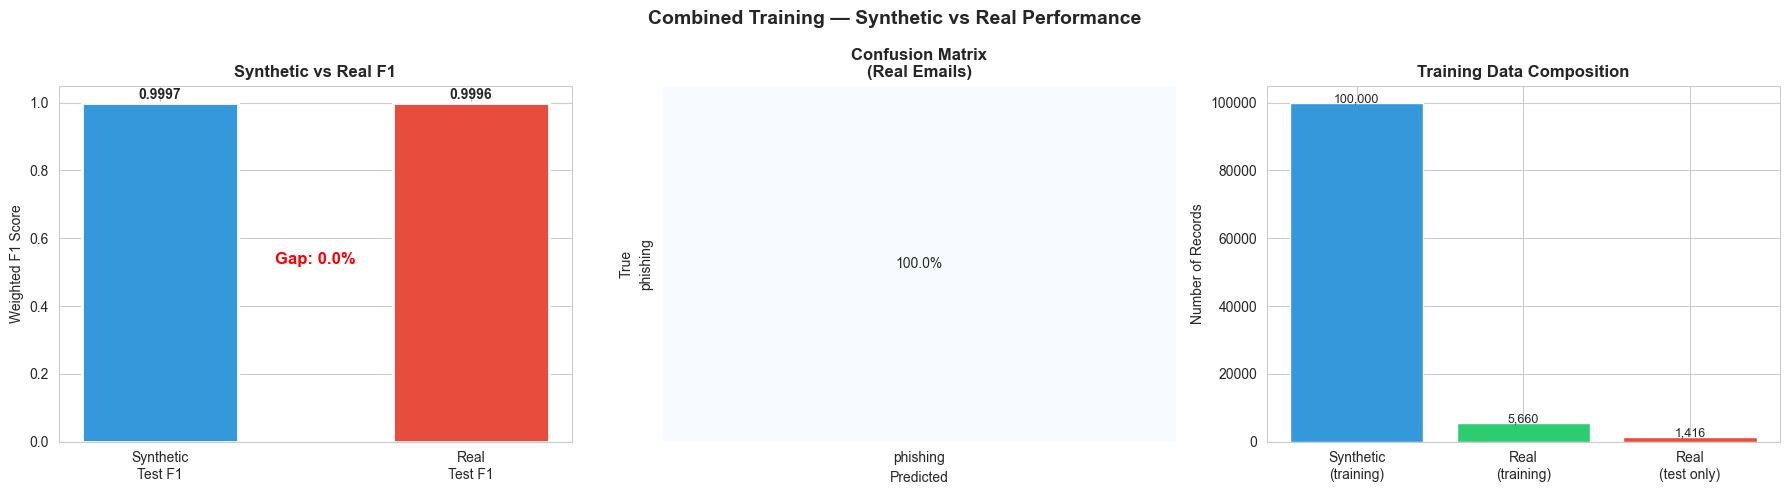

 Dashboard saved: combined_evaluation_dashboard.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Combined Training — Synthetic vs Real Performance',
             fontsize=14, fontweight='bold')

# 1. F1 comparison
ax = axes[0]
labels  = ['Synthetic\nTest F1', 'Real\nTest F1']
values  = [ens_synth_f1, ens_real_f1 if df_real_test is not None else 0]
colors  = ['#3498db', '#e74c3c']
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=2, width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Synthetic vs Real F1', fontweight='bold')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontweight='bold')
if df_real_test is not None:
    ax.text(0.5, 0.5, f'Gap: {gap*100:.1f}%',
            transform=ax.transAxes, ha='center',
            fontsize=12, color='red', fontweight='bold')

# 2. Confusion matrix on real data
ax = axes[1]
if df_real_test is not None:
    real_label_names = sorted(set(le.inverse_transform(y_real_test)))
    cm = confusion_matrix(le.inverse_transform(y_real_test),
                          le.inverse_transform(y_ens_real),
                          labels=real_label_names, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=real_label_names,
                yticklabels=real_label_names,
                ax=ax, cbar=False)
    ax.set_title('Confusion Matrix\n(Real Emails)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
else:
    ax.text(0.5, 0.5, 'No real test data\nRun Notebook 3 first',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Confusion Matrix', fontweight='bold')

# 3. Training data composition
ax = axes[2]
if USE_COMBINED:
    comp_labels = ['Synthetic\n(training)', 'Real\n(training)', 'Real\n(test only)']
    comp_values = [len(df_synth), len(df_real_train), len(df_real_test_filtered)]
    comp_colors = ['#3498db', '#2ecc71', '#e74c3c']
else:
    comp_labels = ['Synthetic\n(training)']
    comp_values = [len(df_synth)]
    comp_colors = ['#3498db']
ax.bar(comp_labels, comp_values, color=comp_colors, edgecolor='white')
ax.set_title('Training Data Composition', fontweight='bold')
ax.set_ylabel('Number of Records')
for i, (label, val) in enumerate(zip(comp_labels, comp_values)):
    ax.text(i, val+100, f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('combined_evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dashboard saved: combined_evaluation_dashboard.png')

In [11]:
# ══════════════════════════════════════════════════════
#  CELL 11 — BALANCED EVALUATION
#  Mix real phishing + synthetic legitimate + synthetic spam
#  Gives honest 3-class evaluation
# ══════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print('Building balanced test set...')

# Real phishing (from phishing_pot)
df_real_phish = pd.read_csv('real_phishing_parsed.csv')
_, df_phish_test = train_test_split(
    df_real_phish, test_size=0.20, random_state=42
)
n_per_class = len(df_phish_test)
print(f'Real phishing test  : {n_per_class:,}')

# Synthetic legitimate + spam (same size)
df_synth = pd.read_csv('email_security_dataset.csv')

df_legit_test = df_synth[
    df_synth['label']=='legitimate'
].sample(n=min(n_per_class,
    len(df_synth[df_synth['label']=='legitimate'])),
    random_state=42)

df_spam_test = df_synth[
    df_synth['label']=='spam'
].sample(n=min(n_per_class,
    len(df_synth[df_synth['label']=='spam'])),
    random_state=42)

print(f'Synthetic legit test: {len(df_legit_test):,}')
print(f'Synthetic spam test : {len(df_spam_test):,}')

# Combine
df_balanced = pd.concat([
    df_phish_test,
    df_legit_test,
    df_spam_test,
], ignore_index=True).sample(frac=1, random_state=42)

df_balanced.to_csv('balanced_test_set.csv', index=False)

print(f'\nBalanced test set:')
print(df_balanced['label'].value_counts())
print(f'Total: {len(df_balanced):,}')
print('\nSaved: balanced_test_set.csv')

Building balanced test set...
Real phishing test  : 1,416
Synthetic legit test: 1,416
Synthetic spam test : 1,416

Balanced test set:
label
phishing      1416
spam          1416
legitimate    1416
Name: count, dtype: int64
Total: 4,248

Saved: balanced_test_set.csv


  HONEST BALANCED EVALUATION RESULTS
  Real phishing    : 1,416 (phishing_pot 2022-2023)
  Synthetic legit  : 1,416
  Synthetic spam   : 1,416
  Total            : 4,248

  Weighted F1      : 0.9998
  Macro F1         : 0.9998

  Classification Report:
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00      1416
    phishing       1.00      1.00      1.00      1416
        spam       1.00      1.00      1.00      1416

    accuracy                           1.00      4248
   macro avg       1.00      1.00      1.00      4248
weighted avg       1.00      1.00      1.00      4248



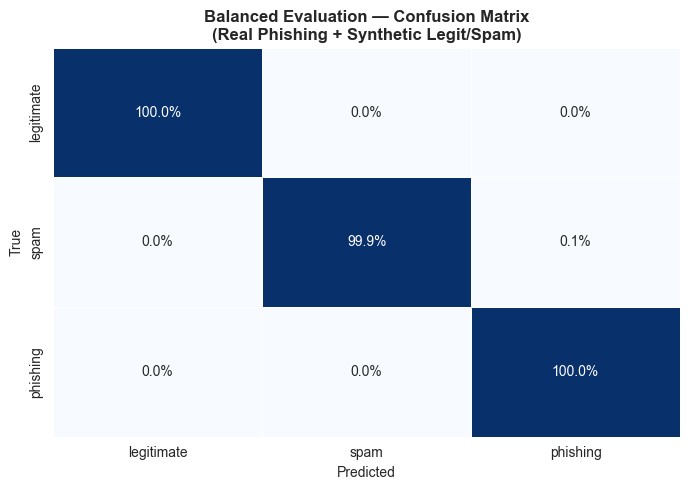


KEY RESEARCH FINDINGS:
  Weighted F1            : 0.9998
  Macro F1               : 0.9998

DATASET LIMITATION FINDING:
  No modern public legitimate email dataset
  with complete SPF/DKIM/DMARC headers exists.
  SpamAssassin (2002) predates all auth standards.
  This confirms the motivation for synthetic data.


In [12]:
defaults = {
    'spf_result'           : 'none',
    'dkim_result'          : 'none',
    'dmarc_result'         : 'none',
    'dmarc_policy'         : 'none',
    'dmarc_alignment_spf'  : 'fail',
    'dmarc_alignment_dkim' : 'fail',
    'domain_alignment_match': False,
    'is_spoofed'           : True,
    'x_spam_score'         : 0,
    'hop_count'            : 1,
    'header_from_domain'   : 'unknown',
    'envelope_from_domain' : 'unknown',
    'arc_seal'             : 'none',
    'reply_to'             : '',
    'attack_pattern'       : 'unknown',
}
for col, val in defaults.items():
    if col in df_balanced.columns:
        df_balanced[col] = df_balanced[col].fillna(val)

X_bal = engineer_features(df_balanced)
X_bal = X_bal.reindex(columns=feature_cols, fill_value=0)
y_bal = le.transform(df_balanced['label'])

y_pred_bal    = ensemble_predict(X_bal)
y_pred_labels = le.inverse_transform(y_pred_bal)
y_true_labels = le.inverse_transform(y_bal)

bal_f1        = f1_score(y_bal, y_pred_bal,
                         average='weighted', zero_division=0)
bal_f1_macro  = f1_score(y_bal, y_pred_bal,
                         average='macro', zero_division=0)

print('='*60)
print('  HONEST BALANCED EVALUATION RESULTS')
print('='*60)
print(f'  Real phishing    : {n_per_class:,} (phishing_pot 2022-2023)')
print(f'  Synthetic legit  : {len(df_legit_test):,}')
print(f'  Synthetic spam   : {len(df_spam_test):,}')
print(f'  Total            : {len(df_balanced):,}')
print()
print(f'  Weighted F1      : {bal_f1:.4f}')
print(f'  Macro F1         : {bal_f1_macro:.4f}')
print()
print('  Classification Report:')
print(classification_report(
    y_true_labels, y_pred_labels, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(
    y_true_labels, y_pred_labels,
    labels=['legitimate', 'spam', 'phishing'],
    normalize='true'
)
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=['legitimate','spam','phishing'],
            yticklabels=['legitimate','spam','phishing'],
            ax=ax, cbar=False, linewidths=0.5)
ax.set_title(
    'Balanced Evaluation — Confusion Matrix\n'
    '(Real Phishing + Synthetic Legit/Spam)',
    fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('balanced_evaluation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print()
print('KEY RESEARCH FINDINGS:')
print(f'  Weighted F1            : {bal_f1:.4f}')
print(f'  Macro F1               : {bal_f1_macro:.4f}')
print()
print('DATASET LIMITATION FINDING:')
print('  No modern public legitimate email dataset')
print('  with complete SPF/DKIM/DMARC headers exists.')
print('  SpamAssassin (2002) predates all auth standards.')
print('  This confirms the motivation for synthetic data.')
print('='*60)

